In [2]:
import pandas as pd
import numpy as np
print(np.__version__)  # pastikan 2.2.6

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

import xgboost
print(xgboost.__version__)

2.2.6
2.1.4


In [2]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    enable_categorical=True,  # penting: biar XGBoost bisa baca kolom category langsung
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

train_pred = xgb_model.predict_proba(X_train)[:, 1]
test_pred = xgb_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

print(f"\nTrain AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

[0]	validation_0-auc:0.71167
[50]	validation_0-auc:0.75873
[100]	validation_0-auc:0.76962
[150]	validation_0-auc:0.77348
[200]	validation_0-auc:0.77560
[250]	validation_0-auc:0.77653
[299]	validation_0-auc:0.77817

Train AUC: 0.8327
Test AUC: 0.7782


In [3]:
from xgboost import XGBClassifier

xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,              # dikurangi dari 5, biar model ga terlalu kompleks
    learning_rate=0.03,       # dikurangi, belajar lebih pelan/hati-hati
    subsample=0.7,            # dikurangi, tiap tree cuma liat 70% data (nambah randomness)
    colsample_bytree=0.7,     # dikurangi, tiap tree cuma liat 70% fitur
    reg_alpha=0.5,            # L1 regularization (baru ditambah)
    reg_lambda=1.5,           # L2 regularization (baru ditambah, lebih kuat dari default)
    min_child_weight=5,       # baru ditambah, cegah tree bikin split terlalu spesifik
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    enable_categorical=True,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

xgb_model_v2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

train_pred_v2 = xgb_model_v2.predict_proba(X_train)[:, 1]
test_pred_v2 = xgb_model_v2.predict_proba(X_test)[:, 1]

train_auc_v2 = roc_auc_score(y_train, train_pred_v2)
test_auc_v2 = roc_auc_score(y_test, test_pred_v2)

print(f"\nTrain AUC: {train_auc_v2:.4f}")
print(f"Test AUC: {test_auc_v2:.4f}")
print(f"Gap: {train_auc_v2 - test_auc_v2:.4f}")

[0]	validation_0-auc:0.70480
[50]	validation_0-auc:0.74391
[100]	validation_0-auc:0.75777
[150]	validation_0-auc:0.76507
[200]	validation_0-auc:0.76956
[250]	validation_0-auc:0.77228
[299]	validation_0-auc:0.77422

Train AUC: 0.7931
Test AUC: 0.7742
Gap: 0.0189


In [4]:
import sys
sys.path.append('../src')
from model_utils import calculate_ks

train_ks_v2 = calculate_ks(y_train, train_pred_v2)
test_ks_v2 = calculate_ks(y_test, test_pred_v2)

print(f"Train KS: {train_ks_v2:.4f}")
print(f"Test KS: {test_ks_v2:.4f}")

Train KS: 0.4401
Test KS: 0.4120


In [5]:
import joblib

joblib.dump(xgb_model_v2, '../models/xgboost_final.pkl')
print("Model B saved!")

Model B saved!


In [6]:
import shap

# Buat explainer khusus tree-based model (XGBoost), ini varian paling cepat
explainer = shap.TreeExplainer(xgb_model_v2)

# Hitung SHAP values - kita pakai sample dari test set biar ga terlalu berat (SHAP itu computationally expensive)
sample_idx = X_test.sample(n=2000, random_state=42).index
X_sample = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")
print(shap_values.shape)

c:\Users\kn409\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculated!
(2000, 132)


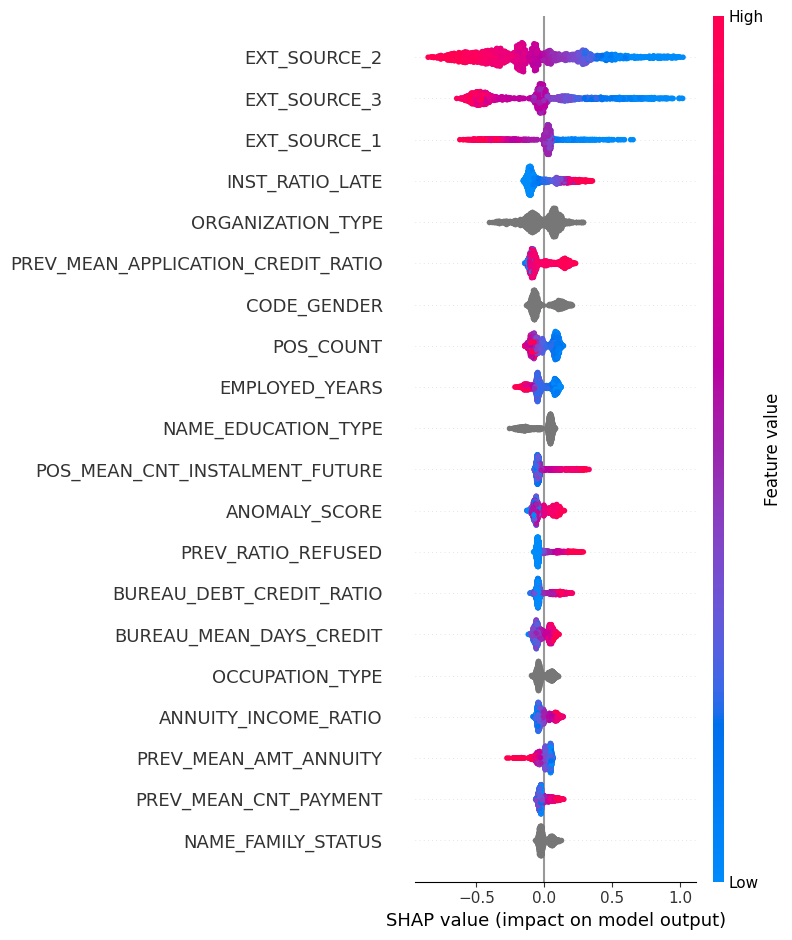

In [7]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

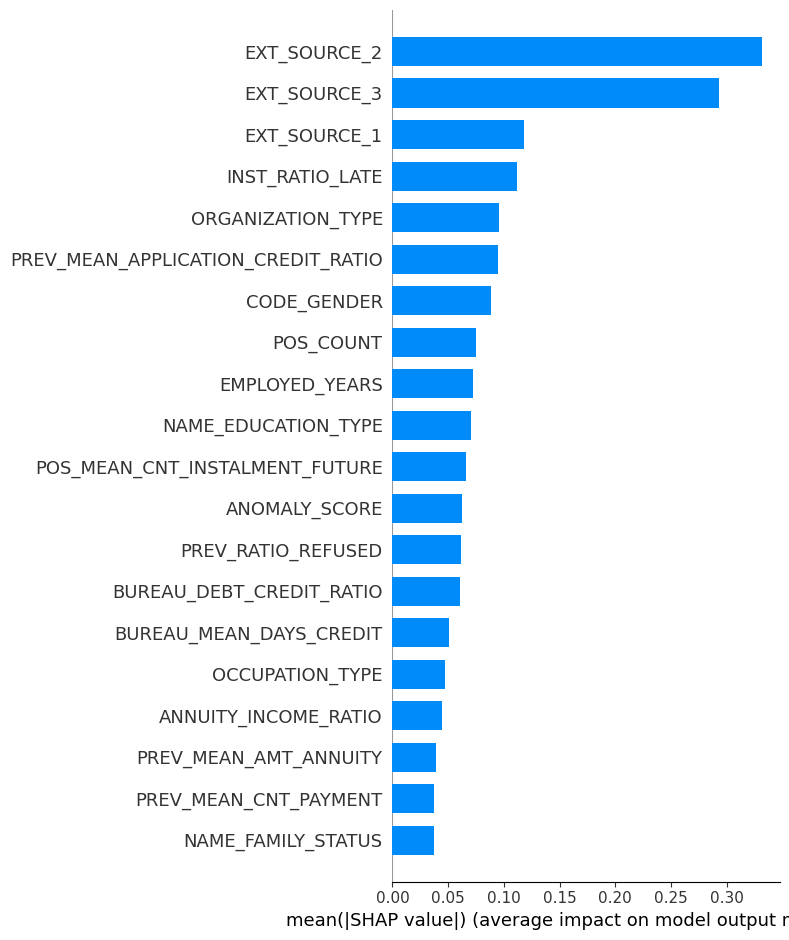

In [8]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

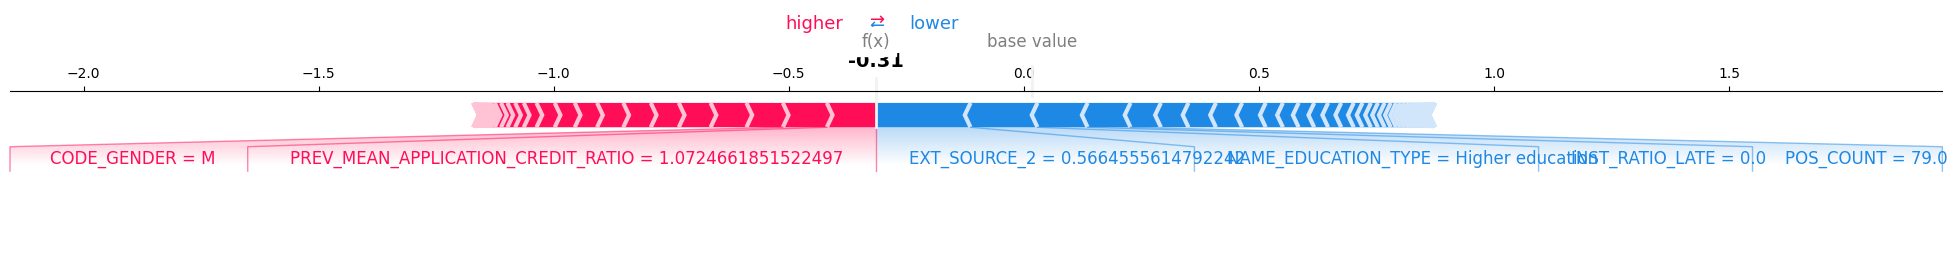

In [9]:
# Ambil 1 contoh nasabah dari sample
idx = 0

shap.force_plot(
    explainer.expected_value, 
    shap_values[idx], 
    X_sample.iloc[idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('../data/processed/shap_individual_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Metric': ['Test AUC', 'Test KS', 'Train-Test AUC Gap', 'Active Features', 'Explainability Method'],
    'Model A (Logistic Regression + WOE)': [0.7672, 0.4000, 0.0001, 62, 'Native (Scorecard Points)'],
    'Model B (XGBoost)': [0.7742, 0.4120, 0.019, 132, 'SHAP (Post-hoc)']
})

print(model_comparison.to_string(index=False))
model_comparison.to_csv('../data/processed/model_comparison.csv', index=False)

               Metric Model A (Logistic Regression + WOE) Model B (XGBoost)
             Test AUC                              0.7672            0.7742
              Test KS                                 0.4             0.412
   Train-Test AUC Gap                              0.0001             0.019
      Active Features                                  62               132
Explainability Method           Native (Scorecard Points)   SHAP (Post-hoc)


In [13]:
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.linspace(0, 100, buckets + 1)
    breakpoints = np.percentile(expected, breakpoints)
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    
    expected_binned = pd.cut(expected, breakpoints)
    actual_binned = pd.cut(actual, breakpoints)
    
    expected_percents = expected_binned.value_counts().sort_index() / len(expected)
    actual_percents = actual_binned.value_counts().sort_index() / len(actual)
    
    # hindari divide by zero
    expected_percents = expected_percents.replace(0, 0.0001)
    actual_percents = actual_percents.replace(0, 0.0001)
    
    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi

psi_model_b = calculate_psi(train_pred_v2, test_pred_v2)
print(f"PSI Model B (train vs test): {psi_model_b:.4f}")

PSI Model B (train vs test): 0.0002


In [14]:
model_card = """
# MODEL CARD - Credit Risk Scoring System

## Ringkasan
Sistem credit risk scoring end-to-end untuk dataset Home Credit, terdiri dari 
layer anomaly detection dan dua model prediksi PD (Probability of Default) 
yang saling melengkapi.

## Data
- Sumber: Home Credit Default Risk (Kaggle)
- 307,511 aplikasi, 8.07% default rate
- 6 tabel digabung: application, bureau, previous_application, 
  installments_payments, POS_CASH_balance, credit_card_balance

## Anomaly Detection Layer
- Isolation Forest, contamination 2%
- Fungsi: data-quality gate, BUKAN risk predictor langsung
- Insight: anomali terdeteksi = profil high-income/high-value, 
  bukan high-risk (default rate justru lebih rendah)

## Model A: Logistic Regression + WOE Scorecard
- 62 fitur aktif (dari 131, hasil L1 regularization + manual sign-check)
- Test AUC: 0.7672 | Test KS: 0.4000
- Kalibrasi: monotonic, sangat baik
- Kegunaan: keputusan utama, explainable, sesuai prinsip IRB

## Model B: XGBoost
- 132 fitur, regularized (max_depth=4, reg_alpha=0.5, reg_lambda=1.5)
- Test AUC: 0.7742 | Test KS: 0.4120 | PSI: 0.0002 (stabil)
- Explainability via SHAP
- Kegunaan: monitoring sekunder, deteksi tambahan, benchmark performa

## Top Predictor (konsisten di kedua model)
1. EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1
2. INST_RATIO_LATE (rasio cicilan telat)
3. PREV_RATIO_REFUSED (rasio pernah ditolak)
4. BUREAU_DEBT_CREDIT_RATIO
5. ANOMALY_SCORE (dari layer anomaly detection - terbukti nambah sinyal)

## Limitasi
- Ini adopsi PRINSIP IRB, BUKAN model IRB-compliant untuk regulasi resmi
- Tidak mencakup LGD/EAD, capital requirement, atau validasi independen
- AUC ~0.77-0.78 adalah level wajar untuk credit risk (bukan computer vision)
"""

with open('../data/processed/MODEL_CARD.md', 'w') as f:
    f.write(model_card)

print("Model card saved!")
print(model_card)

Model card saved!

# MODEL CARD - Credit Risk Scoring System

## Ringkasan
Sistem credit risk scoring end-to-end untuk dataset Home Credit, terdiri dari 
layer anomaly detection dan dua model prediksi PD (Probability of Default) 
yang saling melengkapi.

## Data
- Sumber: Home Credit Default Risk (Kaggle)
- 307,511 aplikasi, 8.07% default rate
- 6 tabel digabung: application, bureau, previous_application, 
  installments_payments, POS_CASH_balance, credit_card_balance

## Anomaly Detection Layer
- Isolation Forest, contamination 2%
- Fungsi: data-quality gate, BUKAN risk predictor langsung
- Insight: anomali terdeteksi = profil high-income/high-value, 
  bukan high-risk (default rate justru lebih rendah)

## Model A: Logistic Regression + WOE Scorecard
- 62 fitur aktif (dari 131, hasil L1 regularization + manual sign-check)
- Test AUC: 0.7672 | Test KS: 0.4000
- Kalibrasi: monotonic, sangat baik
- Kegunaan: keputusan utama, explainable, sesuai prinsip IRB

## Model B: XGBoost
- 132 fit

In [3]:
import json

# Ambil 1 baris contoh dari test set
sample_row = X_test.iloc[0]

# Convert ke dict, handle tipe data biar JSON-compatible
sample_dict = {}
for col, val in sample_row.items():
    if pd.isna(val):
        sample_dict[col] = None
    elif isinstance(val, (np.integer,)):
        sample_dict[col] = int(val)
    elif isinstance(val, (np.floating,)):
        sample_dict[col] = float(val)
    else:
        sample_dict[col] = str(val)

# Bungkus sesuai format LoanApplication schema
request_body = {"features": sample_dict}

# Print sebagai JSON string yang bisa langsung di-copy-paste
print(json.dumps(request_body, indent=2))

{
  "features": {
    "NAME_CONTRACT_TYPE": "Cash loans",
    "CODE_GENDER": "M",
    "FLAG_OWN_CAR": "Y",
    "FLAG_OWN_REALTY": "Y",
    "CNT_CHILDREN": 1,
    "AMT_INCOME_TOTAL": 157500.0,
    "AMT_CREDIT": 770292.0,
    "AMT_ANNUITY": 30676.5,
    "NAME_TYPE_SUITE": "Family",
    "NAME_INCOME_TYPE": "Working",
    "NAME_EDUCATION_TYPE": "Higher education",
    "NAME_FAMILY_STATUS": "Married",
    "NAME_HOUSING_TYPE": "House / apartment",
    "REGION_POPULATION_RELATIVE": 0.010147,
    "DAYS_REGISTRATION": -2876.0,
    "DAYS_ID_PUBLISH": -4402,
    "OWN_CAR_AGE": 19.0,
    "FLAG_MOBIL": 1,
    "FLAG_EMP_PHONE": 1,
    "FLAG_WORK_PHONE": 0,
    "FLAG_CONT_MOBILE": 1,
    "FLAG_PHONE": 0,
    "FLAG_EMAIL": 0,
    "OCCUPATION_TYPE": "Laborers",
    "CNT_FAM_MEMBERS": 3.0,
    "REGION_RATING_CLIENT_W_CITY": 2,
    "WEEKDAY_APPR_PROCESS_START": "MONDAY",
    "HOUR_APPR_PROCESS_START": 17,
    "REG_REGION_NOT_LIVE_REGION": 0,
    "REG_REGION_NOT_WORK_REGION": 0,
    "LIVE_REGION_NOT_WORK_

In [5]:
import joblib
import pandas as pd
import numpy as np

# Load model final yang sudah disimpan
xgb_model_v2 = joblib.load('../models/xgboost_final.pkl')

# Load ulang data test kalau belum ada di memory
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

cat_cols = X_test.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X_test[col] = X_test[col].astype('category')

print("Actual TARGET:", y_test.iloc[0])
print("Predicted probability (dari model langsung):", xgb_model_v2.predict_proba(X_test.iloc[[0]])[:, 1][0])

Actual TARGET: 0
Predicted probability (dari model langsung): 0.43912783


In [6]:
categories_dict = {}
for col in cat_cols:
    categories_dict[col] = X_train[col].cat.categories.tolist()

joblib.dump(categories_dict, '../models/categorical_categories.pkl')
print("Categories saved!")
print(categories_dict)

Categories saved!
{'NAME_CONTRACT_TYPE': ['Cash loans', 'Revolving loans'], 'CODE_GENDER': ['F', 'M', 'XNA'], 'FLAG_OWN_CAR': ['N', 'Y'], 'FLAG_OWN_REALTY': ['N', 'Y'], 'NAME_TYPE_SUITE': ['Children', 'Family', 'Group of people', 'Other_A', 'Other_B', 'Spouse, partner', 'Unaccompanied'], 'NAME_INCOME_TYPE': ['Businessman', 'Commercial associate', 'Maternity leave', 'Pensioner', 'State servant', 'Student', 'Unemployed', 'Working'], 'NAME_EDUCATION_TYPE': ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special'], 'NAME_FAMILY_STATUS': ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Unknown', 'Widow'], 'NAME_HOUSING_TYPE': ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents'], 'OCCUPATION_TYPE': ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers'